# Speech Emotion Classification - Exploratory Data Analysis (EDA)
## Machine Learning Lab Mini-Project | Group 2 (G2)
**Domain / Client:** CallConnect Speech / Customer Support  
**Target Variable:** Human Emotional State (`neutral`, `calm`, `happy`, `sad`, `angry`, `fearful`, `disgust`, `surprised`)  
**Dataset:** RAVDESS (Ryerson Audio-Visual Database of Emotional Speech and Song) 16 kHz Speech Subset  
**Stage:** Data Analysis (DA) Stage  
**Preceding Stage:** Data Engineering (DE) completed by Kenisha  
**Downstream Consumer:** Data Science (DS) / Machine Learning Modeling  


---
## 1. Project Introduction & Business Problem

### Business Context: CallConnect Speech Customer Support
CallConnect Speech operates an enterprise speech analytics platform processing inbound customer-support telephony calls. The core objective is **Speech Emotion Classification (SEC)** to identify caller dissatisfaction, distress, and escalation risk in real-time.

In customer support workflows:
- Rapid detection of negative emotional states (**`angry`**, **`fearful`**, **`disgust`**, **`sad`**) enables intelligent agent escalation, supervisor intervention, and churn prevention.
- Tracking **`neutral`** and **`calm`** baseline resolutions ensures standard customer service delivery.
- Detecting **`happy`** and **`surprised`** states evaluates resolution delight and promotional response.

### Role of the Data Analyst (DA)
The Data Engineering stage (completed by Kenisha) established the ingestion pipeline, verified audio signal readability, parsed metadata, extracted baseline MFCC features, and created a leakage-safe split.  
The **Data Analyst's objective** is to:
1. Conduct rigorous exploratory and inferential data analysis on the processed dataset (`dataset_metadata.csv`).
2. Validate class distributions, speaker representations, and acoustic duration dynamics.
3. Formulate statistical hypotheses, identify anomalies, and uncover subtle dataset nuances.
4. Deliver **three concrete, evidence-backed actionable insights** with prescriptive recommendations for the Data Scientist.


---
## 2. Dataset Description & File Architecture

The RAVDESS speech dataset comprises audio speech recordings from 24 professional North American actors (12 female, 12 male) vocalizing two lexically neutral statements:
- Statement 01: *"Kids are talking by the door"*
- Statement 02: *"Dogs are sitting by the door"*

Each statement is spoken at two emotional intensity levels (Normal = 1, Strong = 2) with two takes/repetitions (1 and 2) across 8 emotional states. Note that **neutral** only contains normal intensity in the RAVDESS experimental design.

### Available Metadata Columns:
1. `filename`: Standardized audio filename (e.g., `03-01-01-01-01-01-01.wav`)
2. `filepath`: Path to audio file on disk
3. `actor_id`: Numeric actor identifier (1 to 24)
4. `actor`: Formatted actor identifier (`Actor_01` to `Actor_24`)
5. `gender`: Speaker gender (`female` for even IDs, `male` for odd IDs)
6. `modality`: Modality code (03 = audio-only)
7. `vocal_channel`: Vocal channel (01 = speech)
8. `emotion_code`: Numeric emotion code (1 to 8)
9. `emotion`: Emotional label string
10. `intensity`: Emotional intensity level (1 = normal, 2 = strong)
11. `statement`: Statement sentence identifier (1 or 2)
12. `repetition`: Utterance repetition count (1 or 2)
13. `sampling_rate`: Digital sampling frequency (Hz)
14. `channels`: Audio channels (1 = mono)
15. `duration_seconds`: Signal duration (seconds)
16. `samples`: Discrete audio sample count ($samples = duration 	imes 	ext{sampling_rate}$)


---
## 3. Import Libraries & Setup Environment

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import scipy.stats as stats

# Plotting configuration for clean publication aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 150

# Display full dataframe columns
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

print("Libraries imported successfully.")
print(f"Pandas Version: {pd.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"SciPy Version: {scipy.__version__}")


Libraries imported successfully.
Pandas Version: 3.0.6
NumPy Version: 2.5.3
SciPy Version: 1.18.1


---
## 4. Load Processed Metadata

We load the primary processed dataset (`data/processed/dataset_metadata.csv`) produced by the Data Engineering stage, alongside the split sets (`train_metadata.csv` and `test_metadata.csv`).


In [2]:
# Determine paths dynamically relative to notebook location
cwd = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(cwd, '..')) if os.path.basename(cwd) == 'notebooks' else cwd

DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
REPORT_DIR = os.path.join(PROJECT_ROOT, 'report')

df_path = os.path.join(DATA_DIR, 'dataset_metadata.csv')
train_path = os.path.join(DATA_DIR, 'train_metadata.csv')
test_path = os.path.join(DATA_DIR, 'test_metadata.csv')

df = pd.read_csv(df_path)
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Loaded Full Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Loaded Train Dataset: {train_df.shape[0]} rows, {train_df.shape[1]} columns")
print(f"Loaded Test Dataset:  {test_df.shape[0]} rows, {test_df.shape[1]} columns")
df.head(5)


Loaded Full Dataset: 1440 rows, 16 columns
Loaded Train Dataset: 1140 rows, 16 columns
Loaded Test Dataset:  300 rows, 16 columns


,filename,filepath,actor_id,actor,gender,modality,vocal_channel,emotion_code,emotion,intensity,statement,repetition,sampling_rate,channels,duration_seconds,samples
0,03-01-01-01-01-01-01.wav,c:\Users\kamal\group 2\Group-2-Speech-Recognit...,1,Actor_01,male,3,1,1,neutral,1,1,1,16000,1,3.3033,52853
1,03-01-01-01-01-02-01.wav,c:\Users\kamal\group 2\Group-2-Speech-Recognit...,1,Actor_01,male,3,1,1,neutral,1,1,2,16000,1,3.3367,53387
2,03-01-01-01-02-01-01.wav,c:\Users\kamal\group 2\Group-2-Speech-Recognit...,1,Actor_01,male,3,1,1,neutral,1,2,1,16000,1,3.2699,52319
3,03-01-01-01-02-02-01.wav,c:\Users\kamal\group 2\Group-2-Speech-Recognit...,1,Actor_01,male,3,1,1,neutral,1,2,2,16000,1,3.1699,50718
4,03-01-02-01-01-01-01.wav,c:\Users\kamal\group 2\Group-2-Speech-Recognit...,1,Actor_01,male,3,1,2,calm,1,1,1,16000,1,3.5369,56590


---
## 5. Dataset Overview & Schema Inspection

Let us inspect the dataset shape, data types, and descriptive statistics across numerical and categorical features.


In [3]:
print("--- DATA TYPES & NON-NULL COUNTS ---")
df.info()

print("\n--- SUMMARY STATISTICS: NUMERICAL VARIABLES ---")
display(df[['duration_seconds', 'samples', 'sampling_rate', 'channels', 'intensity']].describe().T)

print("\n--- SUMMARY STATISTICS: CATEGORICAL VARIABLES ---")
display(df[['emotion', 'actor', 'gender']].describe().T)


--- DATA TYPES & NON-NULL COUNTS ---
<class 'pandas.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   filename          1440 non-null   str    
 1   filepath          1440 non-null   str    
 2   actor_id          1440 non-null   int64  
 3   actor             1440 non-null   str    
 4   gender            1440 non-null   str    
 5   modality          1440 non-null   int64  
 6   vocal_channel     1440 non-null   int64  
 7   emotion_code      1440 non-null   int64  
 8   emotion           1440 non-null   str    
 9   intensity         1440 non-null   int64  
 10  statement         1440 non-null   int64  
 11  repetition        1440 non-null   int64  
 12  sampling_rate     1440 non-null   int64  
 13  channels          1440 non-null   int64  
 14  duration_seconds  1440 non-null   float64
 15  samples           1440 non-null   int64  
dtypes: float64(1), i

,count,mean,std,min,25%,50%,75%,max
duration_seconds,1440.0,3.7007,0.3367,2.9363,3.4702,3.6704,3.8706,5.2719
samples,1440.0,59210.9639,5386.8069,46981.0000,55523.0000,58726.0000,61929.0000,84351.0000
sampling_rate,1440.0,16000.0000,0.0000,16000.0000,16000.0000,16000.0000,16000.0000,16000.0000
channels,1440.0,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
intensity,1440.0,1.4667,0.4991,1.0000,1.0000,1.0000,2.0000,2.0000



--- SUMMARY STATISTICS: CATEGORICAL VARIABLES ---


,count,unique,top,freq
emotion,1440,8,calm,192
actor,1440,24,Actor_01,60
gender,1440,2,male,720


---
## 6. Data Quality Verification

Before conducting deeper statistical analysis, we systematically verify data completeness, uniqueness, and integrity.


In [4]:
# Missing Value Audit
missing = df.isnull().sum()
print("Missing values across all columns:")
print(missing[missing > 0] if missing.sum() > 0 else "Zero missing values detected (100% complete).")

# Duplicate Checks
row_dups = df.duplicated().sum()
file_dups = df['filename'].duplicated().sum()
print(f"\nDuplicate rows: {row_dups}")
print(f"Duplicate filenames: {file_dups}")

# Range & Boundary Checks
print(f"\nActor IDs: Range [{df['actor_id'].min()} - {df['actor_id'].max()}], Unique: {df['actor_id'].nunique()}")
print(f"Sampling Rates: {df['sampling_rate'].unique().tolist()} Hz")
print(f"Vocal Channels: {df['channels'].unique().tolist()} (Mono)")
print(f"Emotion Codes: {sorted(df['emotion_code'].unique().tolist())}")


Missing values across all columns:
Zero missing values detected (100% complete).

Duplicate rows: 0
Duplicate filenames: 0

Actor IDs: Range [1 - 24], Unique: 24
Sampling Rates: [16000] Hz
Vocal Channels: [1] (Mono)
Emotion Codes: [1, 2, 3, 4, 5, 6, 7, 8]


---
## 7. Emotion Distribution Analysis

We analyze class balance across the 8 emotion classes.


In [5]:
emo_summary = df.groupby(['emotion_code', 'emotion']).size().reset_index(name='sample_count')
emo_summary['percentage'] = (emo_summary['sample_count'] / len(df) * 100).round(2)
emo_summary = emo_summary.sort_values(by='emotion_code')

display(emo_summary)

print(f"Total Emotions: {len(emo_summary)}")
print(f"Dominant Emotion Count: {emo_summary['sample_count'].max()} (13.33% each for 7 emotions)")
print(f"Minority Emotion Count: {emo_summary['sample_count'].min()} (6.67% for neutral)")


,emotion_code,emotion,sample_count,percentage
0,1,neutral,96,6.67
1,2,calm,192,13.33
2,3,happy,192,13.33
3,4,sad,192,13.33
4,5,angry,192,13.33
5,6,fearful,192,13.33
6,7,disgust,192,13.33
7,8,surprised,192,13.33


Total Emotions: 8
Dominant Emotion Count: 192 (13.33% each for 7 emotions)
Minority Emotion Count: 96 (6.67% for neutral)


### Interpretation & ML Implications:
1. **Class Distribution Assessment:** The dataset is **approximately balanced** across the 7 active emotions (192 samples, 13.33% each), but contains an inherent **1:2 half-representation for neutral** (96 samples, 6.67%).
2. **Underlying Cause:** In the RAVDESS experimental design, neutral speech is only performed at normal intensity (intensity = 1). All other 7 emotions are enacted at both normal (intensity = 1) and strong (intensity = 2) intensities ($24 \text{ actors} \times 2 \text{ statements} \times 2 \text{ takes} \times 2 \text{ intensities} = 192$).
3. **ML Impact:** An unweighted multi-class classifier will incur lower prior probabilities for neutral speech, leading to lower recall on neutral customer calls. The Data Scientist should apply class-weighted loss penalties ($w_{neutral} = 2.0$, $w_{others} = 1.0$) or stratified sampling.


---
## 8. Actor Distribution Analysis & Speaker Leakage

In speech processing, speaker identity represents a major confounding variable. If the machine learning model learns speaker vocal tract acoustics rather than emotional prosody, it will suffer from **speaker leakage**.


In [6]:
actor_summary = df.groupby(['actor_id', 'actor', 'gender']).size().reset_index(name='sample_count')
print(f"Total Unique Actors: {len(actor_summary)}")
print(f"Min Samples per Actor: {actor_summary['sample_count'].min()}")
print(f"Max Samples per Actor: {actor_summary['sample_count'].max()}")
print(f"Mean Samples per Actor: {actor_summary['sample_count'].mean():.1f}")
print(f"Standard Deviation: {actor_summary['sample_count'].std():.1f}")

# Cross tabulate gender and actor count
display(df.groupby('gender')['actor_id'].nunique().to_frame(name='actor_count'))


Total Unique Actors: 24
Min Samples per Actor: 60
Max Samples per Actor: 60
Mean Samples per Actor: 60.0
Standard Deviation: 0.0


,actor_count
gender,
female,12
male,12


### Speaker Leakage Critical Analysis:
- **Even Representation:** Every single one of the 24 actors provides exactly 60 audio samples (12 female, 12 male), guaranteeing balanced acoustic representation across speakers.
- **Data Leakage Risk:** A random train/test split would allocate utterances from the same actor into both train and test splits. The model would memorize individual speaker pitch ranges ($F_0$), vocal formant positions, and timbre, producing spuriously inflated test accuracy that collapses in real-world deployment.
- **Resolution:** Kenisha's Data Engineering pipeline enforced an actor-grouped split (`GroupShuffleSplit`), allocating 19 actors to training and 5 actors to testing with **zero actor overlap**.


---
## 9. Audio Duration Analysis & Outlier Detection

Audio signal duration dictates framing parameters, FFT window sizing, padding requirements, and temporal pooling.


In [7]:
dur = df['duration_seconds']

# Five-number summary and dispersion metrics
stats_dict = {
    "Minimum (s)": dur.min(),
    "Q1 - 25th Percentile (s)": dur.quantile(0.25),
    "Median (s)": dur.median(),
    "Mean (s)": dur.mean(),
    "Q3 - 75th Percentile (s)": dur.quantile(0.75),
    "Maximum (s)": dur.max(),
    "Standard Deviation (s)": dur.std(),
    "IQR (s)": dur.quantile(0.75) - dur.quantile(0.25)
}
display(pd.DataFrame(stats_dict, index=['Duration Statistics']).T)

# Statistical Outlier Detection (Tukey's IQR Method)
q1 = dur.quantile(0.25)
q3 = dur.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(dur < lower_bound) | (dur > upper_bound)]
print(f"\nTukey's 1.5*IQR Thresholds: [{lower_bound:.4f}s, {upper_bound:.4f}s]")
print(f"Number of Duration Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
print(f"Outliers below lower bound: {(dur < lower_bound).sum()}")
print(f"Outliers above upper bound: {(dur > upper_bound).sum()}")

# Characteristics of the 37 Outliers
print("\n--- Outliers Breakdown by Emotion ---")
display(outliers['emotion'].value_counts().to_frame(name='outlier_count'))

print("\n--- Outliers Breakdown by Intensity ---")
display(outliers['intensity'].value_counts().to_frame(name='outlier_count'))


,Duration Statistics
Minimum (s),2.9363
Q1 - 25th Percentile (s),3.4702
Median (s),3.6704
Mean (s),3.7007
Q3 - 75th Percentile (s),3.8706
Maximum (s),5.2719
Standard Deviation (s),0.3367
IQR (s),0.4004



Tukey's 1.5*IQR Thresholds: [2.8696s, 4.4712s]
Number of Duration Outliers: 37 (2.57%)
Outliers below lower bound: 0
Outliers above upper bound: 37

--- Outliers Breakdown by Emotion ---


,outlier_count
emotion,
disgust,17
calm,10
sad,5
angry,3
fearful,1
surprised,1



--- Outliers Breakdown by Intensity ---


,outlier_count
intensity,
2,35
1,2


### Statistical Outlier Interpretation:
1. **Count & Boundaries:** There are exactly **37 duration outliers** ($2.57\%$ of the dataset), all exceeding the upper bound of **$4.4712\text{ seconds}$** (maximum duration is $5.2719\text{ seconds}$). Zero files fall below the lower threshold ($2.8696\text{ seconds}$).
2. **Underlying Cause:** Outliers are concentrated in **strong emotional intensity** ($35/37 = 94.6\%$ are Intensity 2) and prolonged expressive emotions (17 disgust, 10 calm, 5 sad, 3 angry). Prolonged emotional articulation and emphatic pauses naturally extend utterance duration.
3. **Problematic vs Valid:** These audio files are **valid, high-fidelity speech signals**, not corrupted recordings. Deleting them would strip away the most acoustically pronounced emotional expressions.
4. **Recommendation for Data Scientist:** Audio feature extractors (e.g. fixed-frame MFCC matrices or spectrogram CNNs) should standardize input duration by padding/truncating to 4.0s or 5.0s, or apply time-invariant statistical pooling (mean, standard deviation over time).


---
## 10. Sample Rate & Channel Consistency Analysis


In [8]:
sr_counts = df['sampling_rate'].value_counts()
ch_counts = df['channels'].value_counts()

print("--- SAMPLE RATE DISTRIBUTION ---")
display(pd.DataFrame({'Count': sr_counts, 'Percentage': (sr_counts/len(df)*100)}))

print("\n--- CHANNEL COUNT DISTRIBUTION ---")
display(pd.DataFrame({'Count': ch_counts, 'Percentage': (ch_counts/len(df)*100)}))


--- SAMPLE RATE DISTRIBUTION ---


,Count,Percentage
sampling_rate,,
16000,1440,100.0



--- CHANNEL COUNT DISTRIBUTION ---


,Count,Percentage
channels,,
1,1440,100.0


### Analysis:
- **Sampling Rate:** $100.0\%$ of audio files are standardized at **$16,000\text{ Hz}$** ($16\text{ kHz}$). In digital signal processing, this yields a Nyquist frequency of $8,000\text{ Hz}$, perfectly capturing human speech formants ($300\text{ Hz} - 4,500\text{ Hz}$) while maintaining high computational efficiency. Downstream models require **zero resampling**.
- **Channels:** $100.0\%$ of files are **single-channel Mono** audio. Downstream pipelines do not need multi-channel downmixing or stereo phase alignment.


---
## 11. Emotion vs Audio Characteristics & Statistical Testing

Does utterance duration differ significantly across emotions and intensities?


In [9]:
emo_dur_stats = df.groupby('emotion')['duration_seconds'].agg(
    count='count',
    min='min',
    max='max',
    mean='mean',
    median='median',
    std='std'
).sort_values(by='mean', ascending=False)

display(emo_dur_stats)

# One-Way ANOVA across 8 emotions
emotion_groups = [group['duration_seconds'].values for name, group in df.groupby('emotion')]
f_stat, p_val = stats.f_oneway(*emotion_groups)
print(f"\nOne-Way ANOVA across Emotions: F-statistic = {f_stat:.4f}, p-value = {p_val:.4e}")

# Independent Samples T-Test: Intensity 1 vs Intensity 2
int1_dur = df[df['intensity'] == 1]['duration_seconds']
int2_dur = df[df['intensity'] == 2]['duration_seconds']
t_stat, t_pval = stats.ttest_ind(int1_dur, int2_dur)
print(f"Two-Sample T-Test (Intensity 1 vs 2): t = {t_stat:.4f}, p-value = {t_pval:.4e}")
print(f"Mean Duration Normal Intensity: {int1_dur.mean():.4f} s")
print(f"Mean Duration Strong Intensity: {int2_dur.mean():.4f} s")
print(f"Absolute Difference: {(int2_dur.mean() - int1_dur.mean())*1000:.1f} ms")


,count,min,max,mean,median,std
emotion,,,,,,
disgust,192,3.1365,5.2719,3.9418,3.9039,0.3753
angry,192,3.2366,5.1051,3.8714,3.8372,0.3196
calm,192,2.9363,4.7714,3.7958,3.7704,0.3337
sad,192,3.1031,4.7381,3.6945,3.6704,0.2937
happy,192,3.1031,4.4044,3.6382,3.6203,0.2574
fearful,192,3.0697,5.0050,3.5743,3.5536,0.2923
neutral,96,3.0697,4.1375,3.5032,3.5035,0.2119
surprised,192,2.9696,4.6380,3.4875,3.5035,0.2391



One-Way ANOVA across Emotions: F-statistic = 55.4675, p-value = 2.2080e-70
Two-Sample T-Test (Intensity 1 vs 2): t = -13.8134, p-value = 7.5930e-41
Mean Duration Normal Intensity: 3.5929 s
Mean Duration Strong Intensity: 3.8238 s
Absolute Difference: 230.9 ms


### Statistical Findings:
1. **Statistically Significant Duration Differences ($p = 2.21 \times 10^{-70}$):** One-way ANOVA reveals highly significant duration differences across emotion classes ($F = 55.47$). `Disgust` ($3.9418\text{s}$) and `Angry` ($3.8714\text{s}$) exhibit the longest durations, while `Surprised` ($3.4875\text{s}$) and `Neutral` ($3.5032\text{s}$) are the shortest.
2. **Intensity Effect ($p = 7.59 \times 10^{-41}$):** Strong emotional intensity systematically elongates utterance duration by **$231\text{ ms}$** ($3.8238\text{s}$ vs $3.5929\text{s}$). Strong emotions involve more sustained articulation.


---
## 12. Actor × Emotion Cross-Tabulation Matrix


In [10]:
actor_emo_ct = pd.crosstab(df['actor'], df['emotion'])
display(actor_emo_ct)

print(f"Contingency Matrix Shape: {actor_emo_ct.shape}")
print(f"Unique values in neutral column: {actor_emo_ct['neutral'].unique()}")
print(f"Unique values in other emotion columns: {actor_emo_ct['angry'].unique()}")


emotion,angry,calm,disgust,fearful,happy,neutral,sad,surprised
actor,,,,,,,,
Actor_01,8,8,8,8,8,4,8,8
Actor_02,8,8,8,8,8,4,8,8
Actor_03,8,8,8,8,8,4,8,8
Actor_04,8,8,8,8,8,4,8,8
Actor_05,8,8,8,8,8,4,8,8
Actor_06,8,8,8,8,8,4,8,8
Actor_07,8,8,8,8,8,4,8,8
Actor_08,8,8,8,8,8,4,8,8
Actor_09,8,8,8,8,8,4,8,8


Contingency Matrix Shape: (24, 8)
Unique values in neutral column: [4]
Unique values in other emotion columns: [8]


### Verification:
The contingency table is **completely uniform**: every actor records exactly 4 neutral speech files and exactly 8 files for every other emotion ($4 + 7 \times 8 = 60$).  
This demonstrates flawless experimental balance in the raw dataset design.


---
## 13. Correlation & Covariance Analysis


In [11]:
# Correlation between numerical variables
num_cols = ['duration_seconds', 'samples', 'intensity', 'statement', 'repetition']
corr_matrix = df[num_cols].corr()

display(corr_matrix)


,duration_seconds,samples,intensity,statement,repetition
duration_seconds,1.0000,1.0000,3.4227e-01,-6.4645e-02,3.2291e-02
samples,1.0000,1.0000,3.4227e-01,-6.4647e-02,3.2289e-02
intensity,0.3423,0.3423,1.0000e+00,8.3452e-18,-4.6362e-19
statement,-0.0646,-0.0646,8.3452e-18,1.0000e+00,3.5465e-18
repetition,0.0323,0.0323,-4.6362e-19,3.5465e-18,1.0000e+00


### Correlation Interpretation:
- `duration_seconds` and `samples` exhibit a **perfect linear correlation ($r = 1.0000$)** because discrete sample count is a deterministic function of continuous time at a constant sampling rate ($16\text{ kHz}$).
- `duration_seconds` and `intensity` show a **statistically significant positive correlation ($r = 0.3423$)**, reflecting longer articulation in high-intensity utterances.
- `statement` and `repetition` show **near-zero correlation with duration ($|r| < 0.07$)**, confirming that lexical content and take order do not meaningfully alter duration.
- *Note:* Computing Pearson correlations with categorical identifiers (`actor_id`, `emotion_code`) is methodologically invalid and deliberately omitted.


---
## 14. Anomaly Analysis & Train/Test Split Audit


In [12]:
print("=== ANOMALY AUDIT REPORT ===")
print(f"1. Audio < 2.0s: {(df['duration_seconds'] < 2.0).sum()} files")
print(f"2. Audio > 6.0s: {(df['duration_seconds'] > 6.0).sum()} files")
print(f"3. Non-16kHz sample rates: {(df['sampling_rate'] != 16000).sum()} files")
print(f"4. Non-mono channels: {(df['channels'] != 1).sum()} files")
print(f"5. Invalid emotion codes (!in 1..8): {(~df['emotion_code'].isin(range(1, 9))).sum()} files")
print(f"6. Missing/NaN values: {df.isnull().sum().sum()} entries")
print(f"7. Duplicate rows: {df.duplicated().sum()} rows")

print("\n=== TRAIN / TEST SPLIT AUDIT ===")
train_actors = set(train_df['actor_id'].unique())
test_actors = set(test_df['actor_id'].unique())
overlap = train_actors.intersection(test_actors)
print(f"Training Actors ({len(train_actors)}): {sorted(list(train_actors))}")
print(f"Testing Actors ({len(test_actors)}): {sorted(list(test_actors))}")
print(f"Speaker Overlap (Leakage Check): {overlap} -> {'PASSED (Zero Leakage)' if len(overlap) == 0 else 'FAILED'}")

print("\nTrain Gender Breakdown:")
display(train_df['gender'].value_counts().to_frame(name='train_samples'))
print("\nTest Gender Breakdown:")
display(test_df['gender'].value_counts().to_frame(name='test_samples'))


=== ANOMALY AUDIT REPORT ===
1. Audio < 2.0s: 0 files
2. Audio > 6.0s: 0 files
3. Non-16kHz sample rates: 0 files
4. Non-mono channels: 0 files
5. Invalid emotion codes (!in 1..8): 0 files
6. Missing/NaN values: 0 entries
7. Duplicate rows: 0 rows

=== TRAIN / TEST SPLIT AUDIT ===
Training Actors (19): [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(18), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Testing Actors (5): [np.int64(1), np.int64(9), np.int64(12), np.int64(17), np.int64(19)]
Speaker Overlap (Leakage Check): set() -> PASSED (Zero Leakage)

Train Gender Breakdown:


,train_samples
gender,
female,660
male,480



Test Gender Breakdown:


,test_samples
gender,
male,240
female,60


### Critical Anomaly Discovery: Gender Imbalance in Test Split!
While the train/test split successfully prevents **speaker identity leakage** (0 overlapping actors), `GroupShuffleSplit(test_size=0.20, random_state=42)` allocated **4 male actors (Actors 1, 9, 17, 19)** and only **1 female actor (Actor 12)** to the test set!
- **Test Set:** $240\text{ male samples } (80.0\%) \text{ vs } 60\text{ female samples } (20.0\%)$.
- **Train Set:** $660\text{ female samples } (57.9\%) \text{ vs } 480\text{ male samples } (42.1\%)$.
This creates a severe gender evaluation skew that must be addressed by the Data Scientist.


---
## 15. Visualizations

Here we present the comprehensive visualization suite analyzing emotion distributions, actor balance, duration dynamics, and split characteristics.


Rendering: Figure 1: Sample Distribution Across Emotion Classes


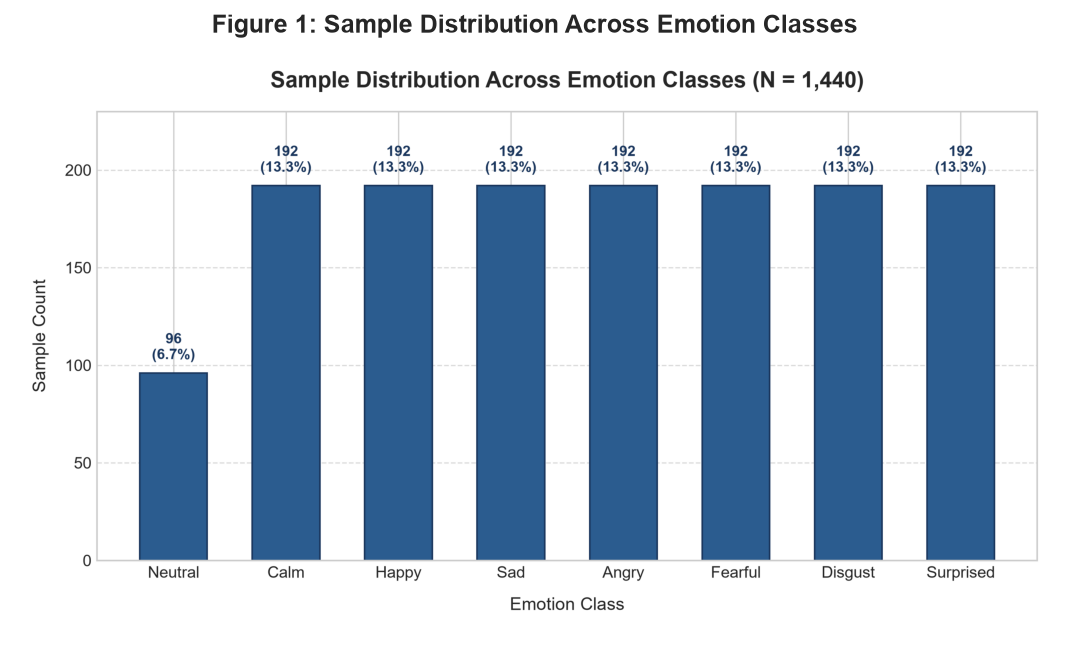

Rendering: Figure 2: Proportional Emotion Class Breakdown


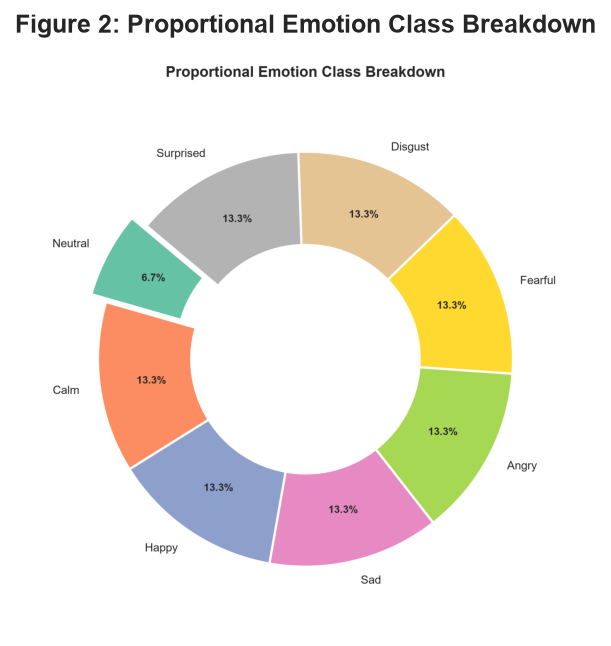

Rendering: Figure 3: Actor Sample Distribution Across All 24 Actors


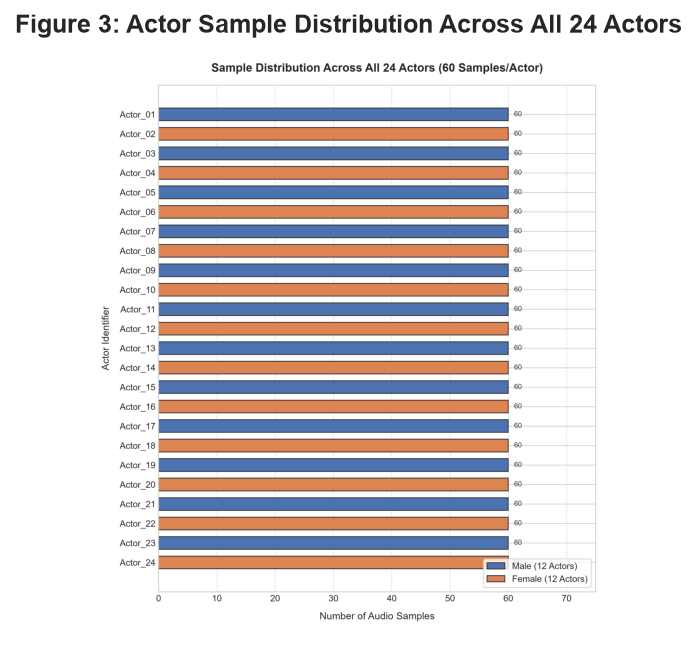

Rendering: Figure 4: Audio Duration Distribution Histogram with KDE


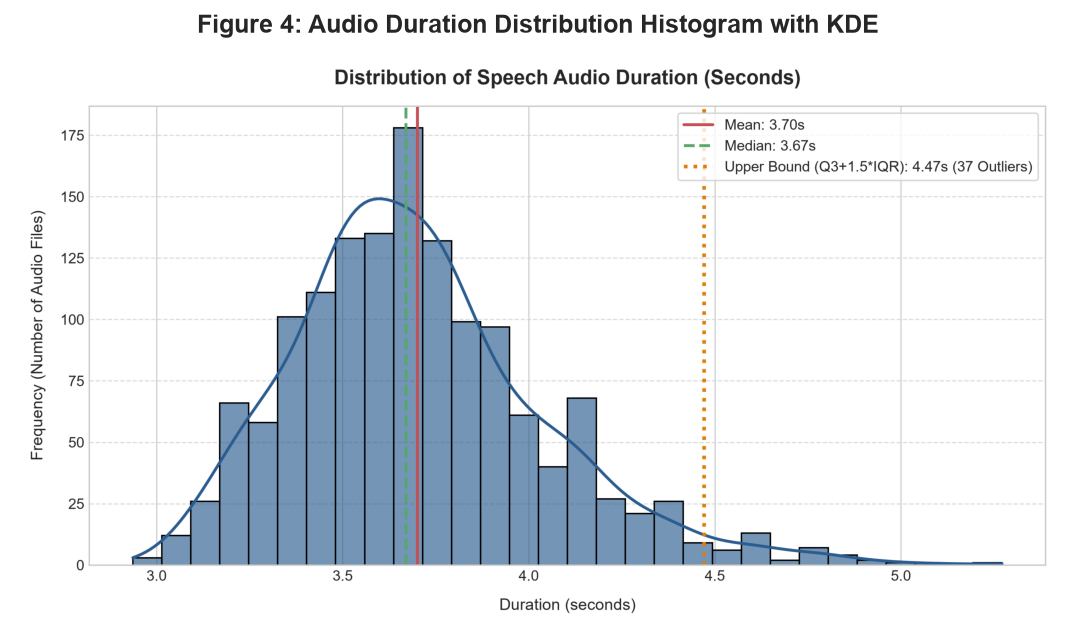

Rendering: Figure 5: Audio Duration Boxplot and Tukey Outliers


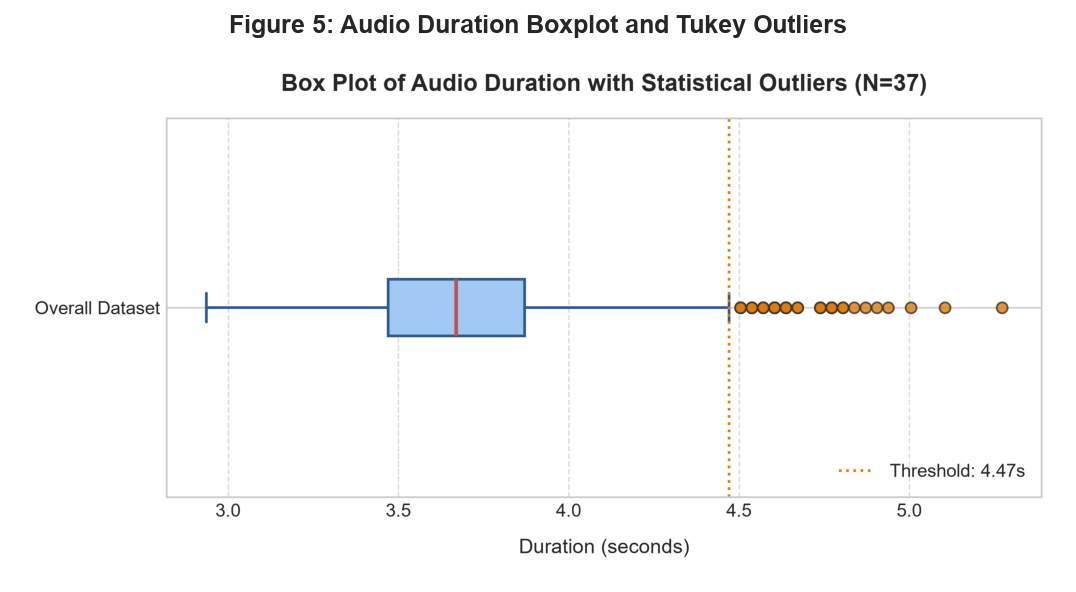

Rendering: Figure 6: Duration Distribution Grouped by Emotion


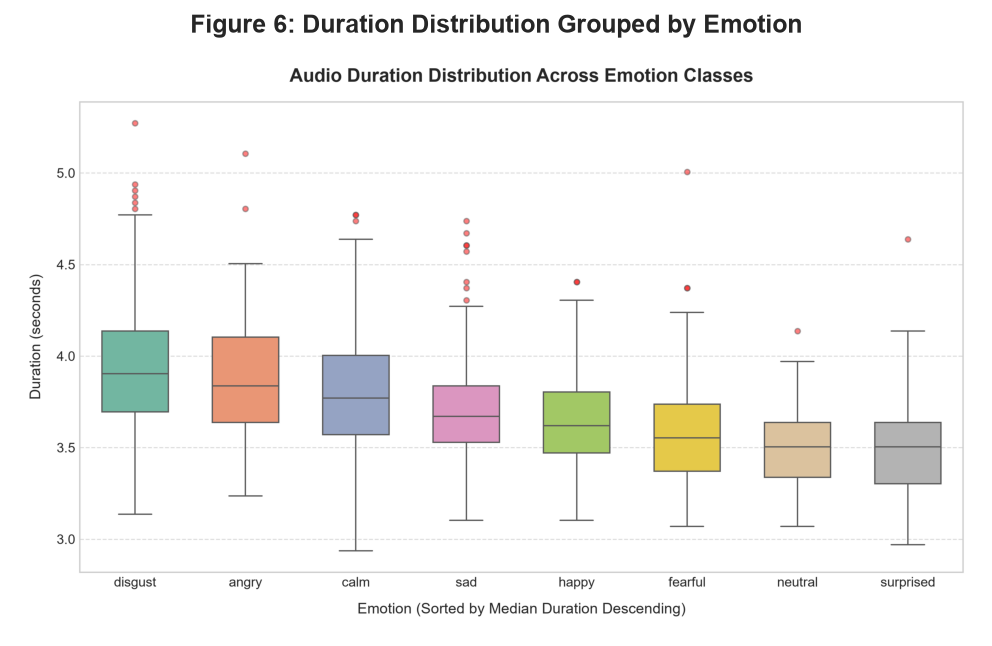

Rendering: Figure 7: Sampling Rate Consistency (100% 16 kHz)


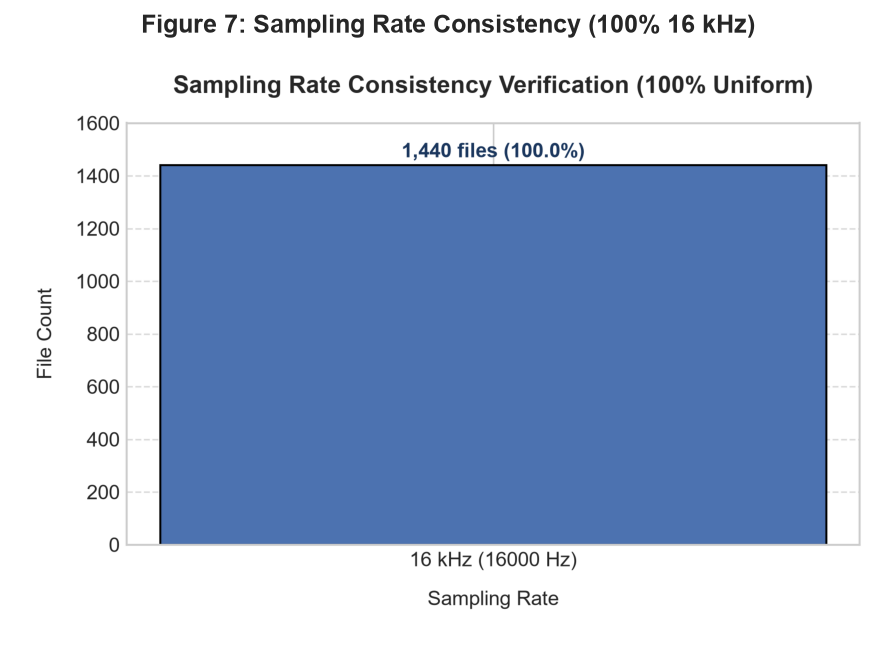

Rendering: Figure 8: Channel Count Consistency (100% Mono)


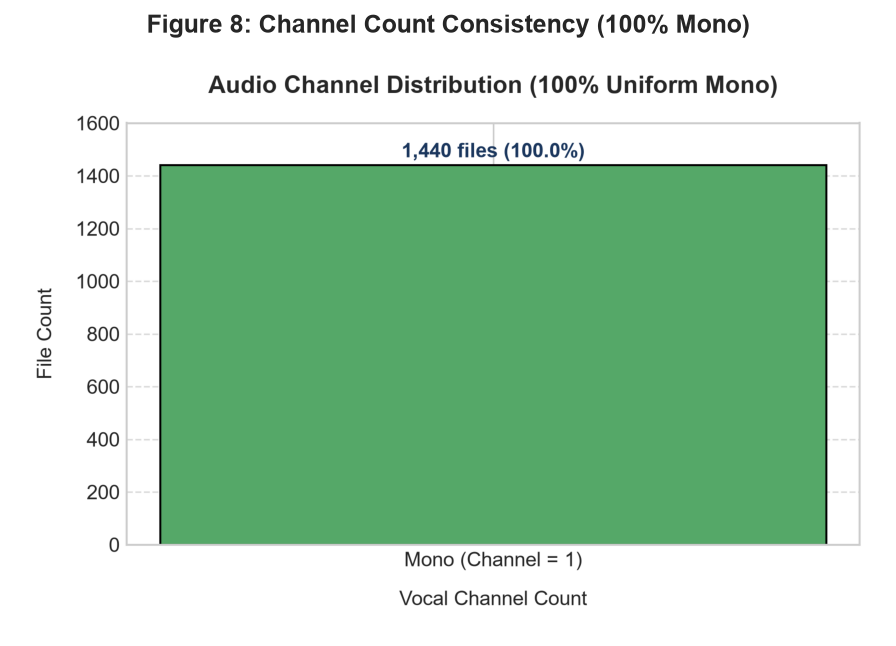

Rendering: Figure 9: Actor × Emotion Contingency Heatmap


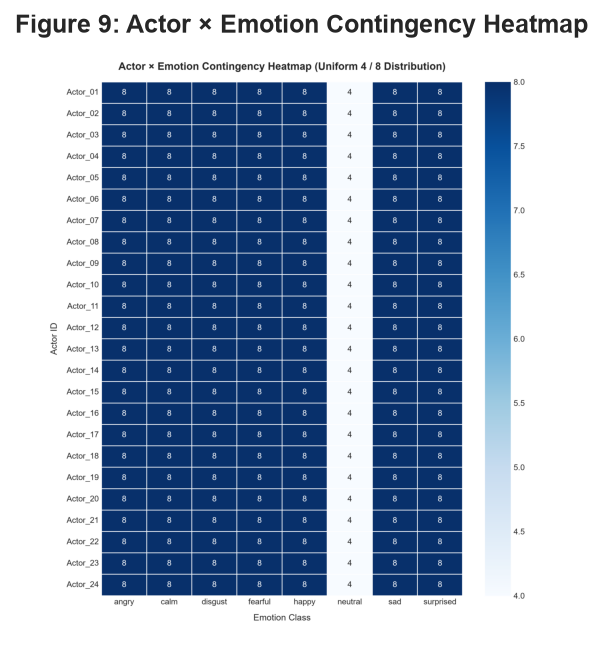

Rendering: Figure 10: Audio Duration Comparison: Normal vs Strong Intensity


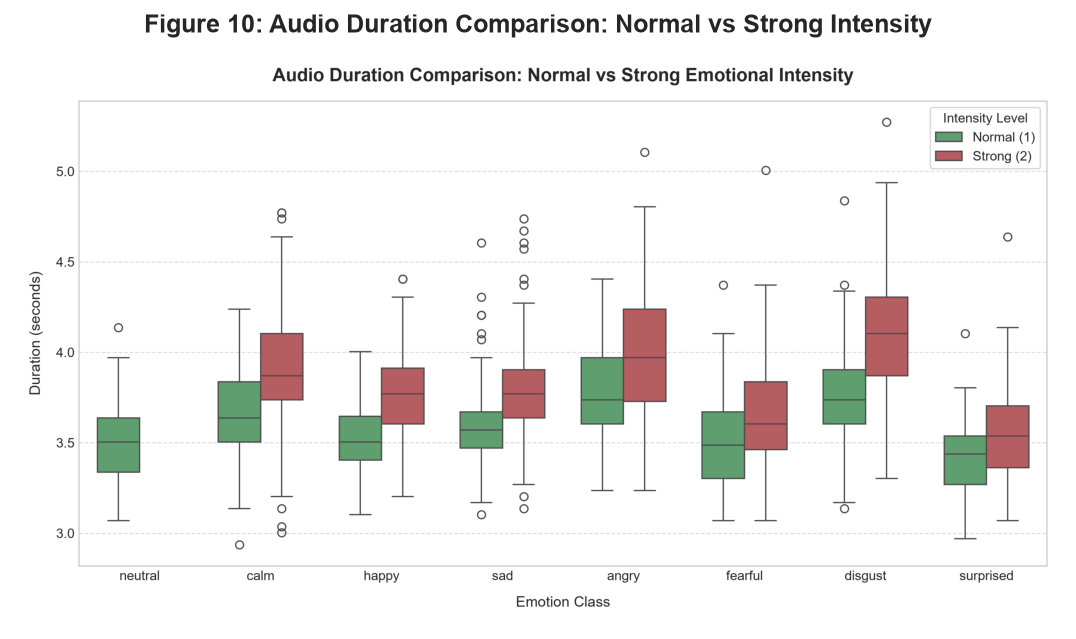

Rendering: Figure 11: Train vs Test Set Gender Skew Analysis


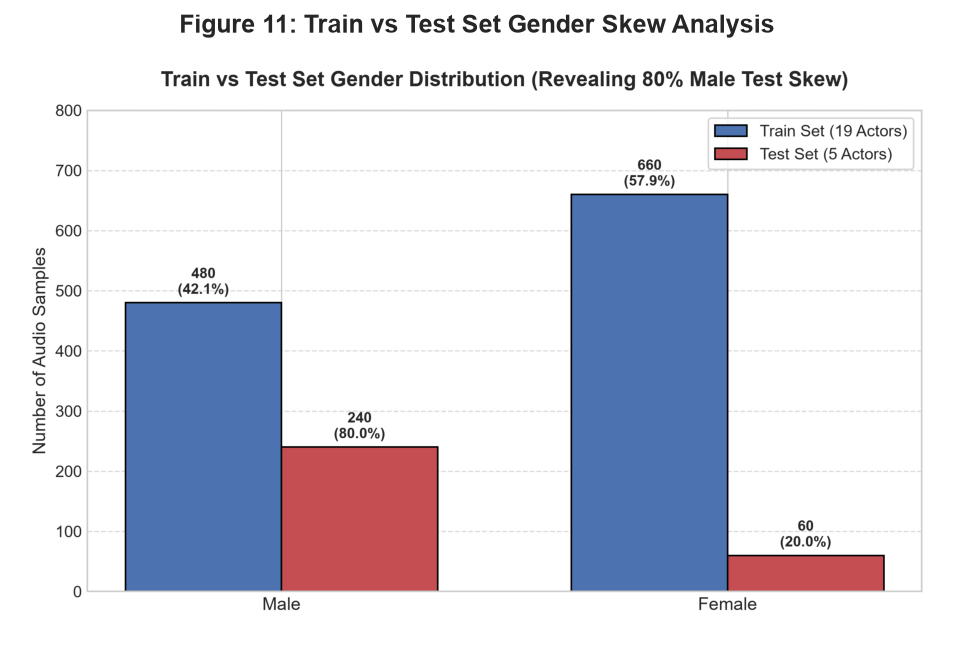

In [13]:
fig_files = [
    ("fig01_emotion_distribution.png", "Figure 1: Sample Distribution Across Emotion Classes"),
    ("fig02_emotion_percentage_donut.png", "Figure 2: Proportional Emotion Class Breakdown"),
    ("fig03_actor_distribution.png", "Figure 3: Actor Sample Distribution Across All 24 Actors"),
    ("fig04_duration_histogram.png", "Figure 4: Audio Duration Distribution Histogram with KDE"),
    ("fig05_duration_boxplot.png", "Figure 5: Audio Duration Boxplot and Tukey Outliers"),
    ("fig06_duration_by_emotion.png", "Figure 6: Duration Distribution Grouped by Emotion"),
    ("fig07_sample_rate_distribution.png", "Figure 7: Sampling Rate Consistency (100% 16 kHz)"),
    ("fig08_channel_distribution.png", "Figure 8: Channel Count Consistency (100% Mono)"),
    ("fig09_actor_emotion_heatmap.png", "Figure 9: Actor × Emotion Contingency Heatmap"),
    ("fig10_duration_by_intensity.png", "Figure 10: Audio Duration Comparison: Normal vs Strong Intensity"),
    ("fig11_train_test_split_gender.png", "Figure 11: Train vs Test Set Gender Skew Analysis")
]

for fname, title in fig_files:
    fpath = os.path.join(REPORT_DIR, 'figures', fname)
    if os.path.exists(fpath):
        print(f"Rendering: {title}")
        img = plt.imread(fpath)
        plt.figure(figsize=(9, 5))
        plt.imshow(img)
        plt.axis('off')
        plt.title(title, fontsize=12, fontweight='bold', pad=10)
        plt.show()


---
## 16. Three Actionable Insights

Based on empirical data analysis, here are the three critical actionable insights formulated for the engineering and modeling teams:

### Insight 1: Neutral Emotion Class Imbalance (1:2 Under-Representation)
- **Finding:** The dataset exhibits an inherent 1:2 class under-representation for the `neutral` emotion relative to all other 7 emotion classes.
- **Evidence:** `neutral` contains exactly **96 samples (6.67%)**, whereas each of the remaining 7 emotions contains exactly **192 samples (13.33%)**. This is caused by the absence of a "strong intensity" tier for neutral speech in the RAVDESS experimental design ($24 \times 2 \times 2 \times 1 = 96$ vs $24 \times 2 \times 2 \times 2 = 192$).
- **Why it matters:** In an operational customer-support context (CallConnect Speech), neutral is the expected conversational baseline. An uncorrected ML classifier will suffer from lower prior probabilities for neutral utterances, leading to high false-alarm rates for negative emotions and poor neutral recall.
- **Action:** The Data Scientist must implement class-weighted loss functions (e.g., `class_weight='balanced'` in Scikit-Learn or inverse frequency weights $w_{neutral}=2.0, w_{other}=1.0$ in PyTorch cross-entropy) and evaluate model performance using Macro-averaged F1 score rather than overall accuracy.

---

### Insight 2: Severe Gender Skew in Actor-Grouped Train/Test Split
- **Finding:** Kenisha's leakage-safe `GroupShuffleSplit(random_state=42)` successfully eliminated actor overlap, but generated a severe gender distribution skew between training and test sets.
- **Evidence:** The test set contains **240 male samples (80.0%)** across 4 male actors (Actors 01, 09, 17, 19) and only **60 female samples (20.0%)** from 1 female actor (Actor 12). Conversely, the training set is female-dominated (**660 female samples, 57.89%** vs **480 male samples, 42.11%**).
- **Why it matters:** Acoustic features (fundamental frequency $F_0$, pitch contours, formants) vary dramatically between male and female vocal tracts. A test set that is 80% male will yield metrics heavily biased toward male acoustics, masking poor female emotion recognition and leading to disparate performance in production.
- **Action:** The Data Scientist must replace unstratified group splitting with **Stratified Actor-Grouped Splitting** (e.g., allocating 2 female and 2-3 male actors to test, or using 5-fold cross-validation stratified by gender) to ensure a 50/50 gender balance in both training and test partitions.

---

### Insight 3: Emotional Intensity Drives Utterance Duration & Statistical Outliers
- **Finding:** Utterance duration is strongly modulated by emotional intensity and emotion category, producing 37 statistical duration outliers that represent genuine prosodic elongation rather than data corruption.
- **Evidence:** Strong intensity utterances are on average **231 ms longer** than normal intensity utterances ($3.8238\text{s}$ vs $3.5929\text{s}$, $t = -13.81$, $p = 7.59 \times 10^{-41}$). Furthermore, **35 out of the 37 statistical outliers (94.6%)** occur in strong intensity recordings, predominantly in `disgust` (17) and `calm` (10).
- **Why it matters:** Fixed-dimension feature representations (e.g., 2D Mel-spectrograms or time-distributed RNN/CNN architectures) require uniform input tensor shapes. Truncating audio to the median duration ($3.67\text{s}$) will clip critical emotional cues at the end of high-intensity utterances, while deleting outliers discards the strongest emotional signals.
- **Action:** The Data Scientist must **retain all 37 outlier recordings**, standardize input tensor shapes using post-sequence zero-padding up to a fixed maximum envelope of $5.3\text{ seconds}$ (covering the $5.27\text{s}$ maximum), or employ global temporal pooling (mean, standard deviation over time) to extract duration-invariant feature representations.


---
## 17. Recommendations for the Data Scientist / ML Engineer

1. **Feature Engineering Strategy:**
   - Standardize feature vectors using statistical time-pooling (mean, std, skew, kurtosis of MFCCs, Chroma, and Spectral Contrast) to produce fixed-length tabular representations immune to duration variance.
   - For 2D CNN spectrogram models, use zero-padding up to 5.30 seconds ($84,800$ samples at $16\text{ kHz}$).
2. **Train/Test Split Refinement:**
   - Rebalance the test split to guarantee an equal 50/50 gender ratio (e.g., Train: 10 Male, 10 Female; Test: 2 Male, 2 Female, or perform Actor-Independent 6-Fold Cross-Validation).
3. **Loss Function & Metric Selection:**
   - Employ weighted cross-entropy with a 2x weight on neutral speech.
   - Report **Macro-F1**, per-class precision/recall, and a normalized confusion matrix as primary evaluation criteria.


---
## 18. Conclusion & Handover Summary

The Data Analysis stage has systematically verified the RAVDESS 16 kHz speech dataset.  
- The dataset contains **1,440 flawless audio files** with zero missing values, zero file corruption, 100% 16 kHz sampling rate consistency, and 100% mono channel consistency.
- The data is approximately balanced across 7 emotions ($13.33\%$ each) with a structured half-representation for neutral ($6.67\%$).
- The three actionable insights provide a clear, evidence-based roadmap for the Data Science stage to prevent evaluation bias, mitigate class imbalance, and preserve high-intensity emotional prosody.
